# Case Study 2 — Tomato Disease Detection (3-Class)
## EfficientNetB0 Transfer Learning + Fine-Tuning

| Item | Detail |
|------|--------|
| **Classes** | Tomato_Bacterial_spot · Tomato_Early_blight · Tomato_Late_blight |
| **Dataset** | PlantVillage — **Balanced: 1000 images/class → 3000 total** |
| **Split** | 70% Train \| 15% Val \| 15% Test |
| **Model** | EfficientNetB0 (ImageNet weights) |
| **Loss** | **Weighted Focal Loss** (alpha per-class, gamma=2) |
| **Visualization** | EfficientNet softmax prediction bar charts |

## 📦 Imports & Configuration

In [3]:
import os, json, random
from collections import defaultdict
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PIL_Image

print('✔ Libraries loaded')

✔ Libraries loaded


In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"c:\Users\prana\OneDrive\Desktop\SUB\SEM 6\NNDL\NNDK")
DATA_DIR    = BASE_DIR / "archive_1" / "PlantVillage"
CS2_DIR     = BASE_DIR / "Case study 2"
OUTPUT_DIR  = CS2_DIR / "outputs"
MODEL_DIR   = OUTPUT_DIR / "models"
LOG_DIR     = OUTPUT_DIR / "logs"
VIZ_DIR     = OUTPUT_DIR / "predictions"

TARGET_CLASSES = [
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
]

IMG_H             = 224
IMG_W             = 224
BATCH_SIZE        = 16
EPOCHS_P1         = 15
EPOCHS_P2         = 15
LR_P1             = 1e-3
LR_P2             = 5e-5
SEED              = 42
TRAIN_SPLIT       = 0.70
VAL_SPLIT         = 0.15
TEST_SPLIT        = 0.15
VIZ_PER_CLS       = 2
SAMPLES_PER_CLASS = 1000   # ← balance: cap each class at 1000 images

for d in [OUTPUT_DIR, MODEL_DIR, LOG_DIR, VIZ_DIR]:
    d.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'✔ GPU : {gpus[0].name}')
else:
    print('⚠ No GPU — training on CPU')

⚠ No GPU — training on CPU


## ⚡ Weighted Focal Loss

```
FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
```
- **alpha_t** = per-class weight (balanced dataset → weights near equal now)  
- **gamma = 2** = focuses loss on misclassified samples  
- Combined with balanced sampling: **double protection** for Early_blight

In [5]:
class WeightedFocalLoss(tf.keras.losses.Loss):
    """
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    alpha : per-class weights  |  gamma : focusing exponent (default 2.0)
    """
    def __init__(self, class_weights, gamma=2.0, name='weighted_focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.class_weights_list = class_weights
        self.gamma = gamma
        self._cw   = tf.constant(class_weights, dtype=tf.float32)

    def call(self, y_true, y_pred):
        y_true  = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        batch   = tf.shape(y_true)[0]
        idx     = tf.stack([tf.range(batch), y_true], axis=1)
        p_t     = tf.gather_nd(y_pred, idx)
        alpha_t = tf.gather(self._cw, y_true)
        focal   = -alpha_t * tf.pow(1.0 - p_t, self.gamma) * tf.math.log(p_t)
        return tf.reduce_mean(focal)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'class_weights': self.class_weights_list, 'gamma': self.gamma})
        return cfg

print('✔ WeightedFocalLoss class defined')

✔ WeightedFocalLoss class defined


## 🗂️ Step 1 — Load & Balance Dataset (1000 images per class)

In [6]:
valid_exts  = {'.jpg', '.jpeg', '.png', '.bmp'}
classes     = sorted(TARGET_CLASSES)
num_classes = len(classes)
name_to_idx = {name: idx for idx, name in enumerate(classes)}
idx_to_name = {idx: name for name, idx in name_to_idx.items()}

print(f'Target classes ({num_classes}):')
for idx, name in idx_to_name.items():
    print(f'  [{idx}]  {name}')
print(f'\nSAMPLES_PER_CLASS = {SAMPLES_PER_CLASS}  (balanced cap)\n')

image_paths, labels = [], []
for cls_name in classes:
    cls_dir   = DATA_DIR / cls_name
    if not cls_dir.is_dir():
        raise FileNotFoundError(f'Class folder not found: {cls_dir}')
    lbl       = name_to_idx[cls_name]
    cls_files = [str(f) for f in cls_dir.iterdir() if f.suffix.lower() in valid_exts]
    # ── Randomly cap at SAMPLES_PER_CLASS ─────────────────────────────────────
    if len(cls_files) > SAMPLES_PER_CLASS:
        cls_files = random.sample(cls_files, SAMPLES_PER_CLASS)
    image_paths.extend(cls_files)
    labels.extend([lbl] * len(cls_files))
    tag = '(capped)' if len(cls_files) == SAMPLES_PER_CLASS else '(all)  '
    print(f'  {cls_name:<35} → {len(cls_files):>4} images  {tag}')

image_paths = np.array(image_paths)
labels      = np.array(labels, dtype=np.int32)
total       = len(labels)
print(f'\nTotal images (balanced) : {total}  ({total//num_classes} per class)')

label_map = {int(k): v for k, v in idx_to_name.items()}
with open(OUTPUT_DIR / 'label_mapping.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print('✔ label_mapping.json saved')

Target classes (3):
  [0]  Tomato_Bacterial_spot
  [1]  Tomato_Early_blight
  [2]  Tomato_Late_blight

SAMPLES_PER_CLASS = 1000  (balanced cap)

  Tomato_Bacterial_spot               → 1000 images  (capped)
  Tomato_Early_blight                 → 1000 images  (capped)
  Tomato_Late_blight                  → 1000 images  (capped)

Total images (balanced) : 3000  (1000 per class)
✔ label_mapping.json saved


In [7]:
# 70 / 15 / 15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels,
    test_size=(VAL_SPLIT + TEST_SPLIT),
    random_state=SEED, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    random_state=SEED, stratify=y_temp
)

print(f'Split (70 / 15 / 15):')
print(f'  Train  : {len(y_train):>5}  images  (~{len(y_train)//num_classes} per class)')
print(f'  Val    : {len(y_val):>5}  images  (~{len(y_val)//num_classes} per class)')
print(f'  Test   : {len(y_test):>5}  images  (~{len(y_test)//num_classes} per class)')

# Compute balanced class weights → used as focal loss alpha
cw_arr  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: float(w) for i, w in enumerate(cw_arr)}
print(f'\nClass weights (focal alpha): {cw_dict}')
print('  (near 1.0 each since dataset is balanced — focal gamma still helps on hard cases)')

focal_loss = WeightedFocalLoss(class_weights=cw_arr.tolist(), gamma=2.0)
print(f'\n✔ WeightedFocalLoss ready  gamma=2.0  alpha={[round(w,3) for w in cw_arr.tolist()]}')

Split (70 / 15 / 15):
  Train  :  2100  images  (~700 per class)
  Val    :   450  images  (~150 per class)
  Test   :   450  images  (~150 per class)

Class weights (focal alpha): {0: 1.0, 1: 1.0, 2: 1.0}
  (near 1.0 each since dataset is balanced — focal gamma still helps on hard cases)

✔ WeightedFocalLoss ready  gamma=2.0  alpha=[1.0, 1.0, 1.0]


## ⚙️ Step 2 — Build tf.data Pipelines

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.20),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
], name='augmentation')

def parse_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_H, IMG_W))
    img = tf.cast(img, tf.float32)
    return img, label

def augment(img, label):
    img = augmentation(img, training=True)
    return img, label

def make_dataset(paths, lbls, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, lbls))
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)
print('✔ tf.data pipelines ready')
print(f'  Train batches : {len(train_ds)}  ({BATCH_SIZE} imgs/batch)')

✔ tf.data pipelines ready
  Train batches : 132  (16 imgs/batch)


## 🧠 Step 3 — Build EfficientNetB0 Model

In [9]:
def build_model(num_classes, trainable_base=False):
    base = EfficientNetB0(
        input_shape=(IMG_H, IMG_W, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base

    inputs = layers.Input(shape=(IMG_H, IMG_W, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inputs, out, name='TomatoDisease_EfficientNetB0'), base

model, base_model = build_model(num_classes, trainable_base=False)
model.summary()

Model: "TomatoDisease_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,415,910 (16.85 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 🏋️ Step 4 — Phase 1: Train Classifier Head (Frozen EfficientNet)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(LR_P1),
    loss=focal_loss,
    metrics=['accuracy']
)

cb_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=4,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(MODEL_DIR / 'best_phase1.keras'),
                    monitor='val_accuracy', save_best_only=True,
                    mode='max', verbose=1),
    CSVLogger(str(LOG_DIR / 'phase1_log.csv'))
]

print('Phase 1: Training classifier head (EfficientNet frozen)...')
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=cb_p1
)
print('\n✔ Phase 1 complete')

Phase 1: Training classifier head (EfficientNet frozen)...
Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6047 - loss: 0.5910
Epoch 1: val_accuracy improved from None to 0.88667, saving model to c:\Users\prana\OneDrive\Desktop\SUB\SEM 6\NNDL\NNDK\Case study 2\outputs\models\best_phase1.keras

Epoch 1: finished saving model to c:\Users\prana\OneDrive\Desktop\SUB\SEM 6\NNDL\NNDK\Case study 2\outputs\models\best_phase1.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 472s 3s/step - accuracy: 0.6895 - loss: 0.4299 - val_accuracy: 0.8867 - val_loss: 0.1716 - learning_rate: 0.0010
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.7873 - loss: 0.2353
Epoch 2: val_accuracy did not improve from 0.88667
132/132 ━━━━━━━━━━━━━━━━━━━━ 74s 517ms/step - accuracy: 0.8057 - loss: 0.2146 - val_accuracy: 0.8533 - val_loss: 0.1455 - learning_rate: 0.0010
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8383 - loss: 0.1561
Epoch 3: val_accuracy improved from 0.88667

## 🔥 Step 5 — Phase 2: Fine-Tune Last 30 EfficientNet Layers

In [11]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers: {n_trainable} / {len(base_model.layers)}')

model.compile(
    optimizer=keras.optimizers.Adam(LR_P2),
    loss=focal_loss,
    metrics=['accuracy']
)

cb_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(str(MODEL_DIR / 'best_phase2.keras'),
                    monitor='val_accuracy', save_best_only=True,
                    mode='max', verbose=1),
    CSVLogger(str(LOG_DIR / 'phase2_log.csv'))
]

print('Phase 2: Fine-tuning last 30 EfficientNet layers...')
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=cb_p2
)

model.save(str(MODEL_DIR / 'tomato3class_efficientnet_final.keras'))
print(f'\n✔ Final model saved → {MODEL_DIR}')

Trainable base layers: 30 / 238
Phase 2: Fine-tuning last 30 EfficientNet layers...
Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.8793 - loss: 0.1238
Epoch 1: val_accuracy improved from None to 0.92222, saving model to c:\Users\prana\OneDrive\Desktop\SUB\SEM 6\NNDL\NNDK\Case study 2\outputs\models\best_phase2.keras

Epoch 1: finished saving model to c:\Users\prana\OneDrive\Desktop\SUB\SEM 6\NNDL\NNDK\Case study 2\outputs\models\best_phase2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 269s 918ms/step - accuracy: 0.8843 - loss: 0.1144 - val_accuracy: 0.9222 - val_loss: 0.0665 - learning_rate: 5.0000e-05
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.9077 - loss: 0.0858
Epoch 2: val_accuracy improved from 0.92222 to 0.93111, saving model to c:\Users\prana\OneDrive\Desktop\SUB\SEM 6\NNDL\NNDK\Case study 2\outputs\models\best_phase2.keras

Epoch 2: finished saving model to c:\Users\prana\OneDrive\Desktop\SUB\SEM 6\NNDL\NNDK\Case study 2\outputs\models\best_p

## 📊 Step 6 — Evaluate on Test Set + Plots

In [12]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'\nTest Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)

print('\n📋 Classification Report:\n')
report = classification_report(
    y_test, y_pred,
    target_names=[idx_to_name[i] for i in range(num_classes)]
)
print(report)

with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f:
    f.write('Case Study 2 — Tomato Disease Detection (3-Class, Balanced 1000/class)\n')
    f.write('='*60 + '\n')
    f.write(f'Loss     : WeightedFocalLoss (gamma=2.0, alpha={[round(w,3) for w in cw_arr.tolist()]})\n')
    f.write(f'Dataset  : {SAMPLES_PER_CLASS} images/class (balanced)\n')
    f.write(f'Classes  : {", ".join(classes)}\n\n')
    f.write(f'Test Accuracy : {test_acc*100:.2f}%\n')
    f.write(f'Test Loss     : {test_loss:.4f}\n\n')
    f.write(report)
print('✔ classification_report.txt saved')

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 410ms/step - accuracy: 0.9644 - loss: 0.0224

Test Accuracy : 96.44%
Test Loss     : 0.0224
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 426ms/step

📋 Classification Report:

                       precision    recall  f1-score   support

Tomato_Bacterial_spot       0.95      0.98      0.97       150
  Tomato_Early_blight       0.98      0.94      0.96       150
   Tomato_Late_blight       0.96      0.97      0.97       150

             accuracy                           0.96       450
            macro avg       0.96      0.96      0.96       450
         weighted avg       0.96      0.96      0.96       450

✔ classification_report.txt saved


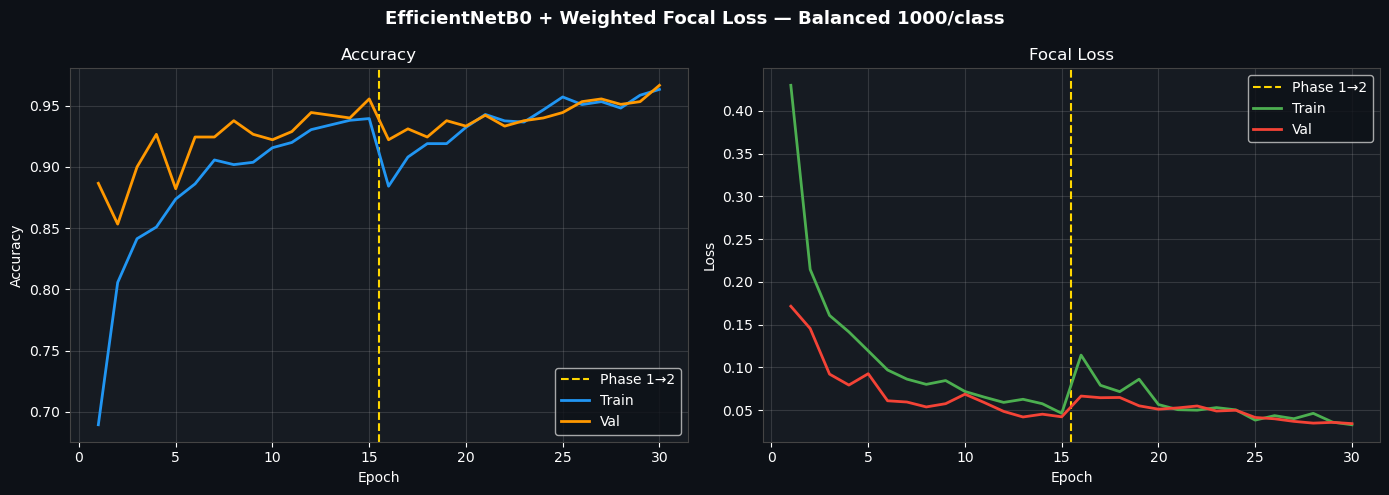

✔ Saved: training_curves.png


In [13]:
def merge_histories(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}

hist       = merge_histories(history1, history2)
ep_range   = range(1, len(hist['accuracy']) + 1)
phase1_end = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0D1117')
fig.suptitle('EfficientNetB0 + Weighted Focal Loss — Balanced 1000/class',
             fontsize=13, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor('#161B22')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
    ax.axvline(x=phase1_end + 0.5, color='#FFD700', linewidth=1.5,
               linestyle='--', label='Phase 1→2')

axes[0].plot(ep_range, hist['accuracy'],     label='Train', color='#2196F3', lw=2)
axes[0].plot(ep_range, hist['val_accuracy'], label='Val',   color='#FF9800', lw=2)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(facecolor='#0D1117', labelcolor='white')
axes[0].grid(True, alpha=0.2)

axes[1].plot(ep_range, hist['loss'],     label='Train', color='#4CAF50', lw=2)
axes[1].plot(ep_range, hist['val_loss'], label='Val',   color='#F44336', lw=2)
axes[1].set_title('Focal Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(facecolor='#0D1117', labelcolor='white')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'training_curves.png'), dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('✔ Saved: training_curves.png')

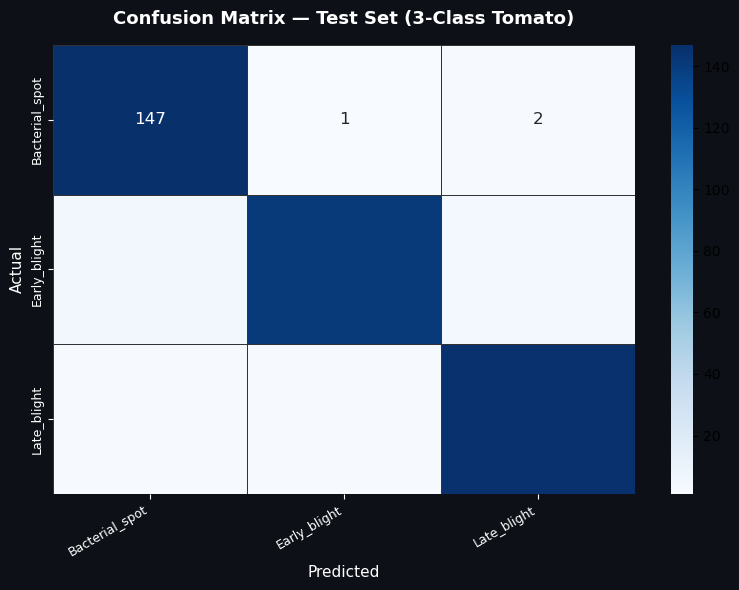

✔ Saved: confusion_matrix.png


In [14]:
cm = confusion_matrix(y_test, y_pred)
short_names = [idx_to_name[i].replace('Tomato_', '') for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0D1117')
ax.set_facecolor('#0D1117')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=ax, linewidths=0.5, linecolor='#333', annot_kws={'size': 12})
ax.set_title('Confusion Matrix — Test Set (3-Class Tomato)',
             color='white', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted', color='white', fontsize=11)
ax.set_ylabel('Actual',    color='white', fontsize=11)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'confusion_matrix.png'), dpi=150,
            bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('✔ Saved: confusion_matrix.png')

## 🔬 Step 7 — EfficientNet Prediction Visualization

Generating 2 prediction card(s) per class ...



C:\Users\prana\AppData\Local\Temp\ipykernel_20080\3146439824.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\prana\AppData\Local\Temp\ipykernel_20080\3146439824.py:69: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(str(VIZ_DIR / out_name), dpi=130,
C:\Users\prana\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


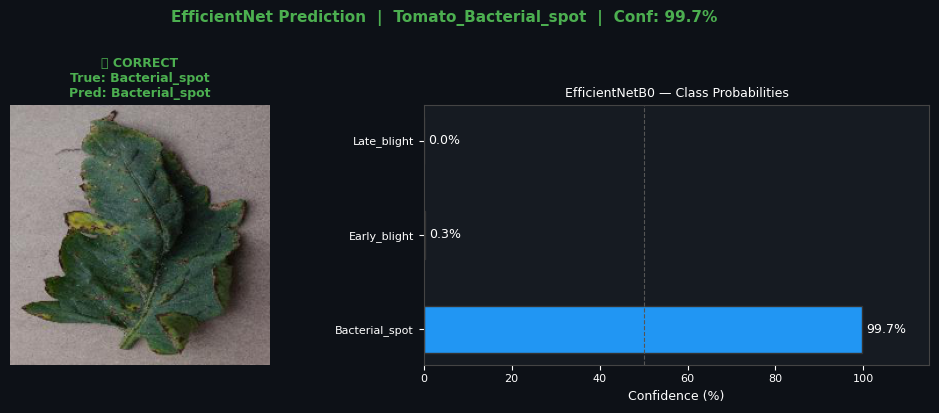

   ✅ [Bacterial_spot                ] conf=99.7%  → Bacterial_spot_pred1.png


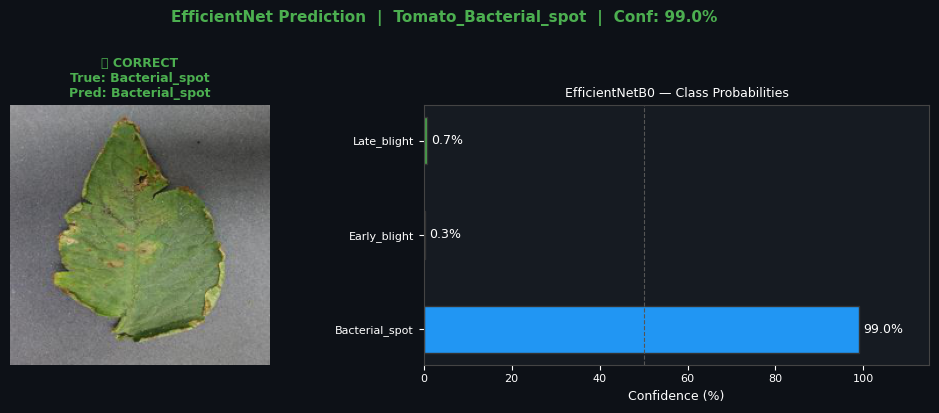

   ✅ [Bacterial_spot                ] conf=99.0%  → Bacterial_spot_pred2.png


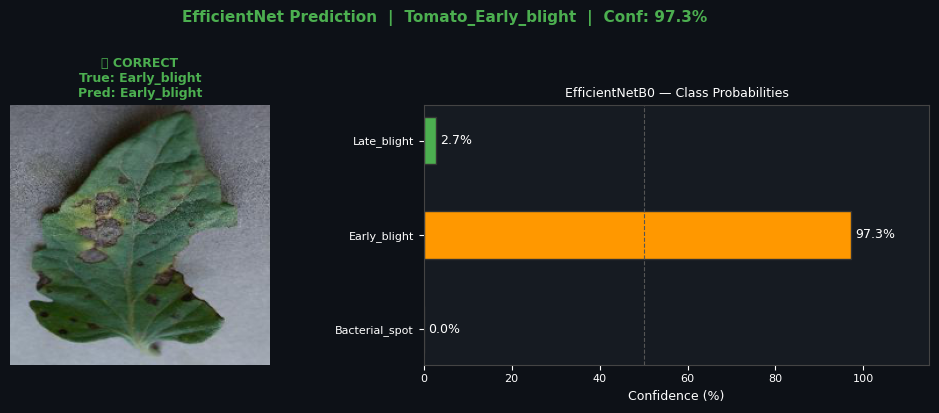

   ✅ [Early_blight                  ] conf=97.3%  → Early_blight_pred1.png


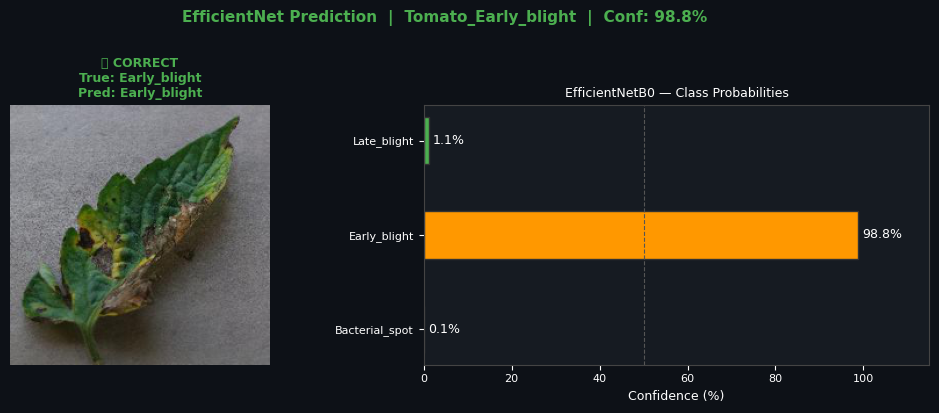

   ✅ [Early_blight                  ] conf=98.8%  → Early_blight_pred2.png


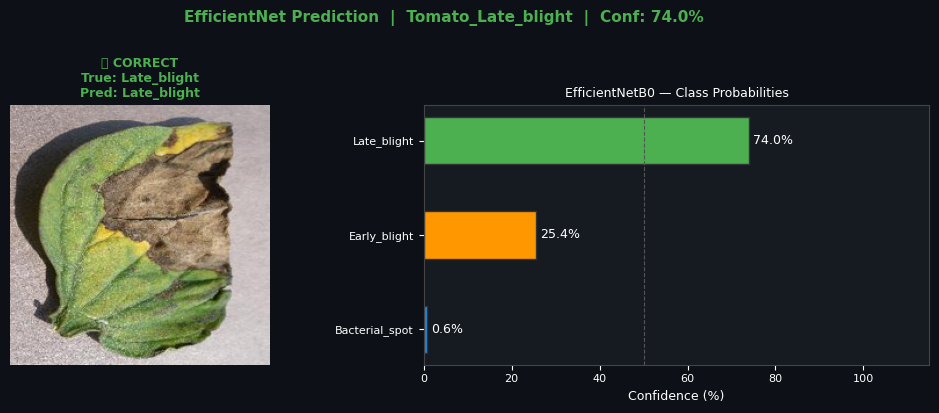

   ✅ [Late_blight                   ] conf=74.0%  → Late_blight_pred1.png


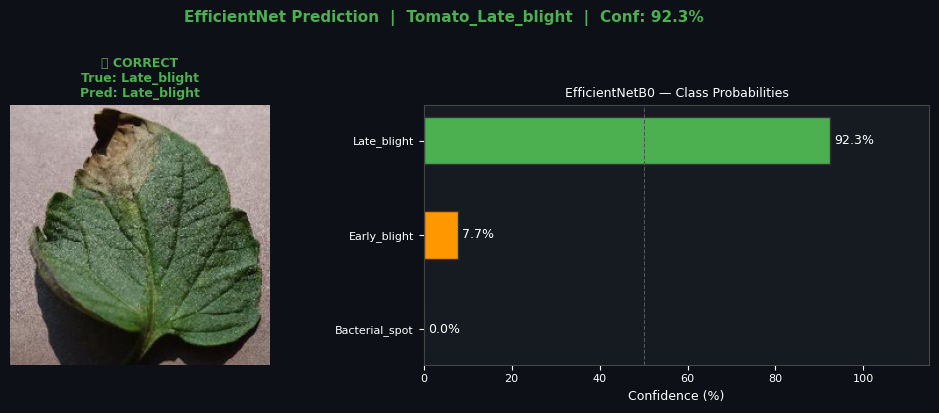

   ✅ [Late_blight                   ] conf=92.3%  → Late_blight_pred2.png


In [15]:
BAR_COLORS = ['#2196F3', '#FF9800', '#4CAF50']

class_to_indices = defaultdict(list)
for i, lbl in enumerate(y_test):
    class_to_indices[lbl].append(i)

summary_rows = []
print(f'Generating {VIZ_PER_CLS} prediction card(s) per class ...\n')

for cls_idx in range(num_classes):
    cls_name  = idx_to_name[cls_idx]
    cls_short = cls_name.replace('Tomato_', '')
    indices   = class_to_indices[cls_idx]
    if not indices:
        continue

    sample_idx = random.sample(indices, min(VIZ_PER_CLS, len(indices)))

    for rank, idx in enumerate(sample_idx):
        img_path   = X_test[idx]
        true_lbl   = int(y_test[idx])
        pred_lbl   = int(y_pred[idx])
        probs      = y_pred_probs[idx]
        confidence = float(probs[pred_lbl])
        correct    = (true_lbl == pred_lbl)

        img_pil = PIL_Image.open(img_path).convert('RGB').resize((IMG_H, IMG_W))
        img_arr = np.array(img_pil)

        status  = '✅ CORRECT' if correct else '❌ WRONG'
        s_color = '#4CAF50'   if correct else '#F44336'

        fig, (ax_img, ax_bar) = plt.subplots(
            1, 2, figsize=(10, 4),
            gridspec_kw={'width_ratios': [1, 1.4]},
            facecolor='#0D1117'
        )
        ax_img.imshow(img_arr)
        ax_img.axis('off')
        ax_img.set_title(
            f'{status}\nTrue: {cls_name.replace("Tomato_","")}\n'
            f'Pred: {idx_to_name[pred_lbl].replace("Tomato_","")}',
            color=s_color, fontsize=9, fontweight='bold', pad=6
        )

        ax_bar.set_facecolor('#161B22')
        snames = [idx_to_name[i].replace('Tomato_', '') for i in range(num_classes)]
        bars   = ax_bar.barh(snames, probs * 100, color=BAR_COLORS,
                             edgecolor='#333', height=0.5)
        for bar, p in zip(bars, probs):
            ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                        f'{p*100:.1f}%', va='center', color='white', fontsize=9)
        ax_bar.set_xlim(0, 115)
        ax_bar.axvline(x=50, color='#555', linewidth=0.8, linestyle='--')
        ax_bar.set_xlabel('Confidence (%)', color='white', fontsize=9)
        ax_bar.tick_params(colors='white', labelsize=8)
        ax_bar.set_title('EfficientNetB0 — Class Probabilities',
                         color='white', fontsize=9, pad=6)
        for spine in ax_bar.spines.values():
            spine.set_edgecolor('#444')

        fig.suptitle(
            f'EfficientNet Prediction  |  {cls_name}  |  Conf: {confidence*100:.1f}%',
            fontsize=11, color=s_color, fontweight='bold', y=1.02
        )
        plt.tight_layout()

        out_name = f'{cls_short}_pred{rank+1}.png'
        plt.savefig(str(VIZ_DIR / out_name), dpi=130,
                    bbox_inches='tight', facecolor='#0D1117')
        plt.show()
        plt.close()

        print(f"   {'✅' if correct else '❌'} [{cls_short:<30}] conf={confidence*100:.1f}%  → {out_name}")
        summary_rows.append((img_arr, cls_name, idx_to_name[pred_lbl], probs, correct))

C:\Users\prana\AppData\Local\Temp\ipykernel_20080\4106832352.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\prana\AppData\Local\Temp\ipykernel_20080\4106832352.py:40: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(str(OUTPUT_DIR / 'efficientnet_pred_summary.png'), dpi=130,


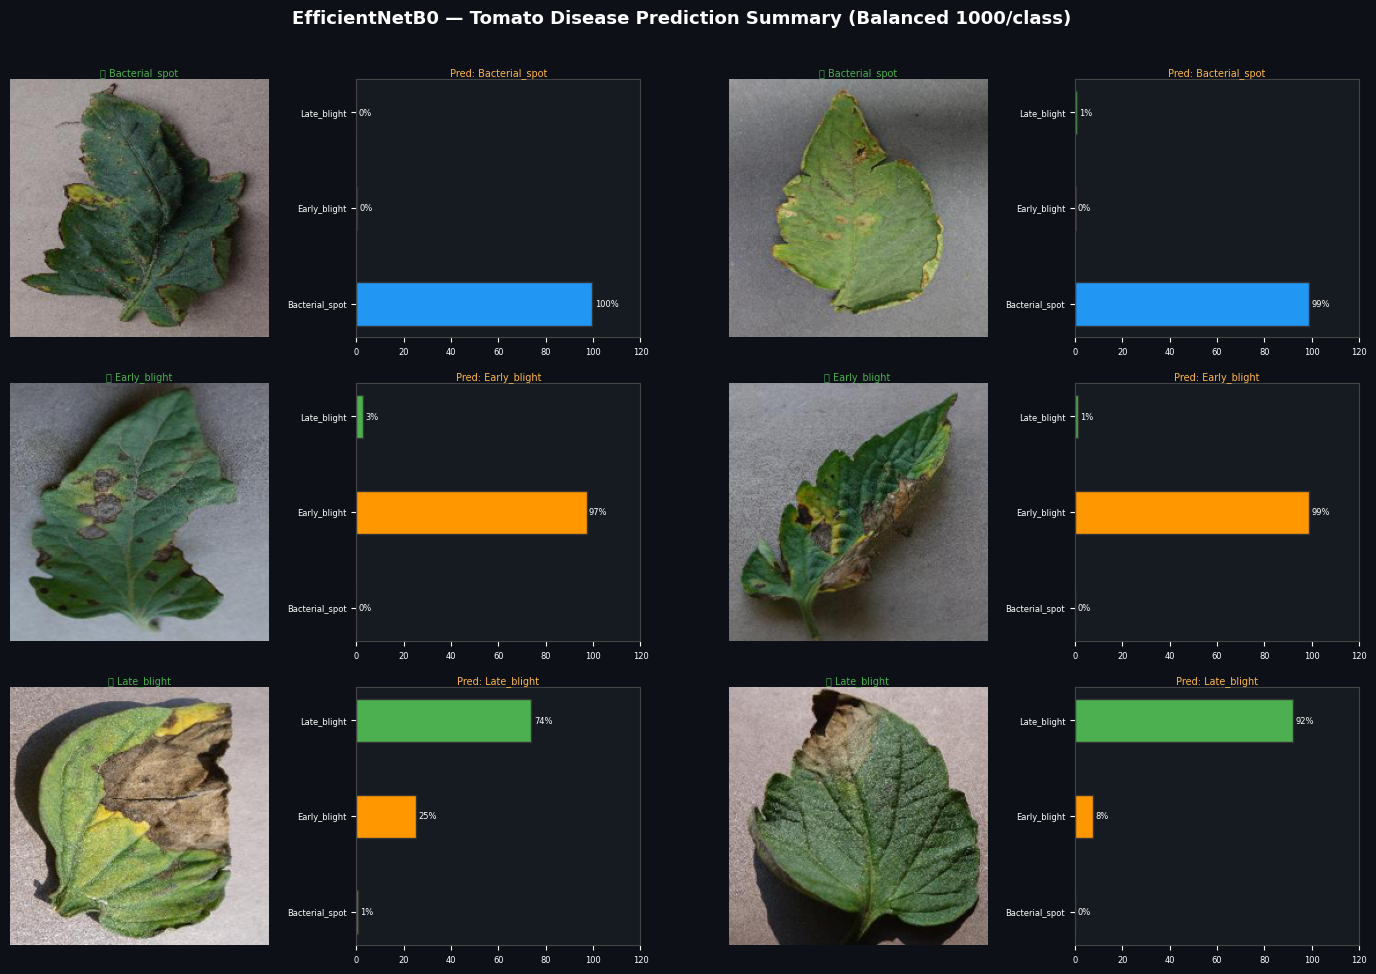

✔ Saved: efficientnet_pred_summary.png


In [16]:
n_samples = len(summary_rows)
grid_rows = (n_samples + 1) // 2
grid_cols = 4

fig, axes = plt.subplots(grid_rows, grid_cols,
                         figsize=(grid_cols * 3.5, grid_rows * 3.2),
                         facecolor='#0D1117')
if grid_rows == 1:
    axes = axes[np.newaxis, :]

fig.suptitle('EfficientNetB0 — Tomato Disease Prediction Summary (Balanced 1000/class)',
             fontsize=13, color='white', fontweight='bold', y=1.01)

for i, (img_arr, true_n, pred_n, probs, ok) in enumerate(summary_rows):
    row = i // 2; col_img = (i % 2) * 2; col_bar = col_img + 1
    sc = '#4CAF50' if ok else '#F44336'

    ax_i = axes[row, col_img]
    ax_i.imshow(img_arr); ax_i.axis('off')
    ax_i.set_title(f"{'✅' if ok else '❌'} {true_n.replace('Tomato_', '')}",
                   color=sc, fontsize=7, pad=3)

    ax_b = axes[row, col_bar]
    ax_b.set_facecolor('#161B22')
    snames = [idx_to_name[j].replace('Tomato_', '') for j in range(num_classes)]
    bars   = ax_b.barh(snames, probs * 100, color=BAR_COLORS, edgecolor='#333', height=0.45)
    for bar, p in zip(bars, probs):
        ax_b.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                  f'{p*100:.0f}%', va='center', color='white', fontsize=6)
    ax_b.set_xlim(0, 120); ax_b.tick_params(colors='white', labelsize=6)
    ax_b.set_title(f"Pred: {pred_n.replace('Tomato_', '')}", color='#FFB74D', fontsize=7, pad=3)
    for spine in ax_b.spines.values(): spine.set_edgecolor('#444')

for j in range(n_samples, grid_rows * 2):
    r, c = divmod(j, 2)
    if r < grid_rows:
        axes[r, c * 2].axis('off'); axes[r, c * 2 + 1].axis('off')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'efficientnet_pred_summary.png'), dpi=130,
            bbox_inches='tight', facecolor='#0D1117')
plt.show(); plt.close()
print('✔ Saved: efficientnet_pred_summary.png')

## 🎉 Final Summary

In [17]:
correct_count = sum(1 for *_, ok in summary_rows if ok)
print('='*60)
print('  🎉  DONE — Outputs saved to: Case study 2/outputs/')
print('='*60)
print(f'  Dataset          : {SAMPLES_PER_CLASS} images/class (balanced)')
print(f'  Total images     : {total}')
print(f'  Classes          : {", ".join(classes)}')
print(f'  Test Accuracy    : {test_acc*100:.2f}%')
print(f'  Test Loss        : {test_loss:.4f}')
print(f'  Viz Correct      : {correct_count}/{len(summary_rows)}')
print(f'\n  📁 Output files:')
print(f'     outputs/training_curves.png')
print(f'     outputs/confusion_matrix.png')
print(f'     outputs/classification_report.txt')
print(f'     outputs/label_mapping.json')
print(f'     outputs/predictions/           ← per-class prediction cards')
print(f'     outputs/efficientnet_pred_summary.png')
print(f'     outputs/models/                ← phase1 / phase2 / final')
print(f'     outputs/logs/                  ← CSV training logs')
print('='*60)

  🎉  DONE — Outputs saved to: Case study 2/outputs/
  Dataset          : 1000 images/class (balanced)
  Total images     : 3000
  Classes          : Tomato_Bacterial_spot, Tomato_Early_blight, Tomato_Late_blight
  Test Accuracy    : 96.44%
  Test Loss        : 0.0224
  Viz Correct      : 6/6

  📁 Output files:
     outputs/training_curves.png
     outputs/confusion_matrix.png
     outputs/classification_report.txt
     outputs/label_mapping.json
     outputs/predictions/           ← per-class prediction cards
     outputs/efficientnet_pred_summary.png
     outputs/models/                ← phase1 / phase2 / final
     outputs/logs/                  ← CSV training logs
